In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import linregress

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [3]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [4]:
fund_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     object 
 2   scheme_name         40 non-null     object 
 3   category            40 non-null     object 
 4   sub_category        40 non-null     object 
 5   plan                40 non-null     object 
 6   launch_date         40 non-null     object 
 7   benchmark           40 non-null     object 
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     object 
 13  risk_category       40 non-null     object 
 14  sebi_category_code  40 non-null     object 
dtypes: float64(2), int64(3), object(10)
memory usage: 4.8+ KB


In [5]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [6]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [7]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [8]:
benchmark.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   object 
 1   index_name   8050 non-null   object 
 2   close_value  8050 non-null   float64
dtypes: float64(1), object(2)
memory usage: 188.8+ KB


In [9]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort values
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily return for each fund
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

print("Daily Returns Calculated Successfully")

Daily Returns Calculated Successfully


In [10]:
nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [11]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

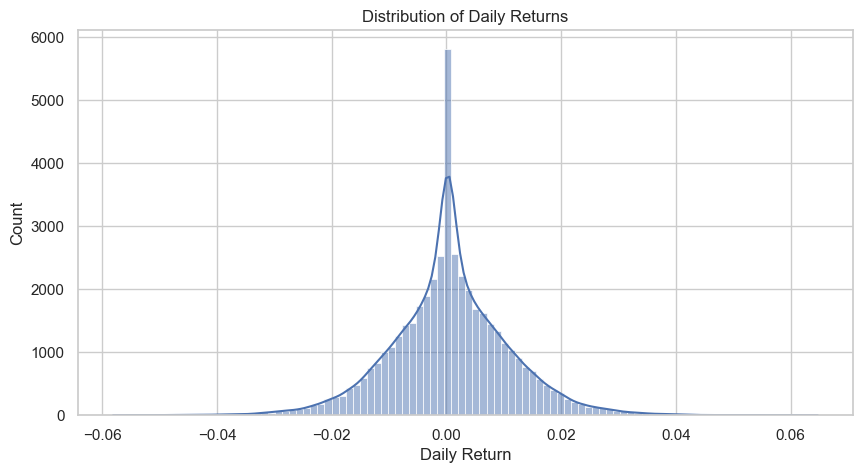

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(nav["daily_return"].dropna(), bins=100, kde=True)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.show()

# CAGR Analysis (1 Year, 3 Year & 5 Year)

In [13]:
# Ensure date is datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort data
nav = nav.sort_values(["amfi_code", "date"])

In [14]:
# First and last NAV for each fund
fund_summary = nav.groupby("amfi_code").agg(
    start_date=("date", "min"),
    end_date=("date", "max"),
    start_nav=("nav", "first"),
    end_nav=("nav", "last")
)

fund_summary.head()

,start_date,end_date,start_nav,end_nav
amfi_code,,,,
100016,2022-01-03,2026-05-29,520.4608,583.6113
100025,2022-01-03,2026-05-29,26.3169,31.8843
100033,2022-01-03,2026-05-29,107.3758,342.0072
101206,2022-01-03,2026-05-29,305.0996,773.2939
101207,2022-01-03,2026-05-29,38.5736,53.9836


In [15]:
# Calculate investment period in years
fund_summary["years"] = (
    (fund_summary["end_date"] - fund_summary["start_date"]).dt.days
) / 365

fund_summary.head()

,start_date,end_date,start_nav,end_nav,years
amfi_code,,,,,
100016,2022-01-03,2026-05-29,520.4608,583.6113,4.40274
100025,2022-01-03,2026-05-29,26.3169,31.8843,4.40274
100033,2022-01-03,2026-05-29,107.3758,342.0072,4.40274
101206,2022-01-03,2026-05-29,305.0996,773.2939,4.40274
101207,2022-01-03,2026-05-29,38.5736,53.9836,4.40274


In [16]:
# CAGR Formula
fund_summary["CAGR"] = (
    (fund_summary["end_nav"] / fund_summary["start_nav"])
    ** (1 / fund_summary["years"])
) - 1

fund_summary.head()

,start_date,end_date,start_nav,end_nav,years,CAGR
amfi_code,,,,,,
100016,2022-01-03,2026-05-29,520.4608,583.6113,4.40274,0.026352
100025,2022-01-03,2026-05-29,26.3169,31.8843,4.40274,0.044551
100033,2022-01-03,2026-05-29,107.3758,342.0072,4.40274,0.300997
101206,2022-01-03,2026-05-29,305.0996,773.2939,4.40274,0.235205
101207,2022-01-03,2026-05-29,38.5736,53.9836,4.40274,0.079331


In [17]:
top_cagr = fund_summary.sort_values("CAGR", ascending=False)

top_cagr.head(10)

,start_date,end_date,start_nav,end_nav,years,CAGR
amfi_code,,,,,,
120505,2022-01-03,2026-05-29,135.8720,473.7640,4.40274,0.328016
119598,2022-01-03,2026-05-29,89.8738,309.2050,4.40274,0.323981
149324,2022-01-03,2026-05-29,81.6814,279.7511,4.40274,0.322621
148569,2022-01-03,2026-05-29,28.8620,97.7435,4.40274,0.319245
148567,2022-01-03,2026-05-29,70.2514,230.2708,4.40274,0.309499
120843,2022-01-03,2026-05-29,49.9131,163.2397,4.40274,0.308833
100033,2022-01-03,2026-05-29,107.3758,342.0072,4.40274,0.300997
149323,2022-01-03,2026-05-29,78.4622,245.3651,4.40274,0.295581
119094,2022-01-03,2026-05-29,68.3023,203.8581,4.40274,0.281926


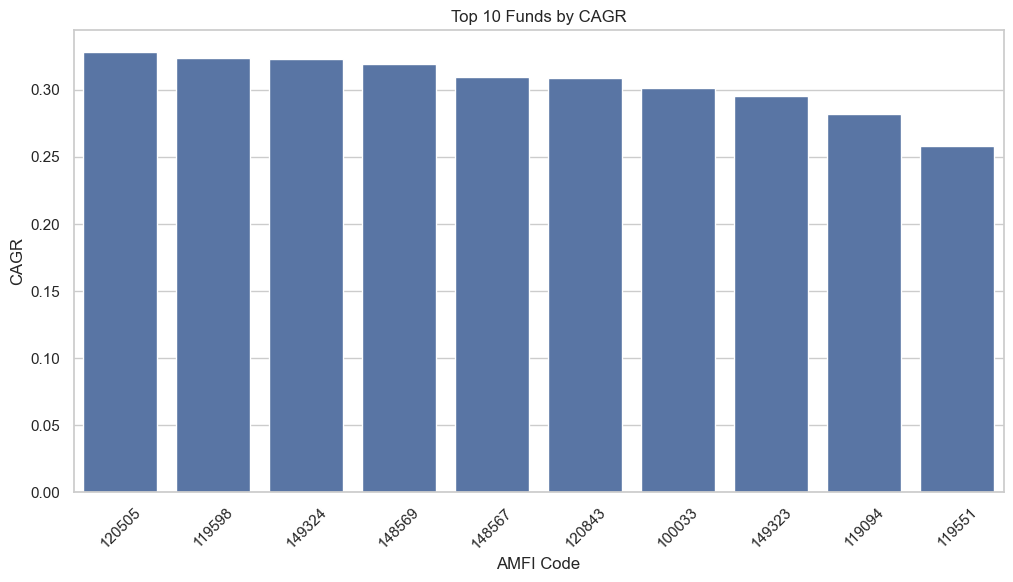

In [18]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_cagr.head(10).index.astype(str),
    y=top_cagr.head(10)["CAGR"]
)

plt.title("Top 10 Funds by CAGR")
plt.xlabel("AMFI Code")
plt.ylabel("CAGR")
plt.xticks(rotation=45)

plt.show()

# Sharpe Ratio Analysis

In [19]:
# Calculate mean and standard deviation of daily returns
sharpe = nav.groupby("amfi_code")["daily_return"].agg(["mean", "std"])

sharpe.head()

,mean,std
amfi_code,,
100016,0.000142,0.009164
100025,0.000170,0.002460
100033,0.001080,0.011929
101206,0.000852,0.009177
101207,0.000424,0.016251


In [20]:
# Risk-free rate
risk_free_rate = 0.065

# Annualize returns and volatility
sharpe["annual_return"] = sharpe["mean"] * 252
sharpe["annual_std"] = sharpe["std"] * np.sqrt(252)

# Sharpe Ratio
sharpe["Sharpe_Ratio"] = (
    (sharpe["annual_return"] - risk_free_rate)
    / sharpe["annual_std"]
)

sharpe.head()

,mean,std,annual_return,annual_std,Sharpe_Ratio
amfi_code,,,,,
100016,0.000142,0.009164,0.035683,0.145481,-0.201517
100025,0.000170,0.002460,0.042854,0.039052,-0.567095
100033,0.001080,0.011929,0.272111,0.189367,1.093699
101206,0.000852,0.009177,0.214647,0.145682,1.027213
101207,0.000424,0.016251,0.106962,0.257973,0.162661


In [21]:
top_sharpe = sharpe.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

top_sharpe.head(10)

,mean,std,annual_return,annual_std,Sharpe_Ratio
amfi_code,,,,,
148567,0.001074,0.008941,0.270566,0.141937,1.448291
120843,0.001082,0.010008,0.272602,0.158870,1.306744
148569,0.001124,0.011134,0.283262,0.176740,1.234930
119551,0.000917,0.008656,0.231033,0.137414,1.208267
120505,0.001161,0.012152,0.292653,0.192909,1.180101
149323,0.001055,0.011179,0.265908,0.177462,1.132122
100033,0.001080,0.011929,0.272111,0.189367,1.093699
118632,0.000865,0.008913,0.218037,0.141484,1.081659
101206,0.000852,0.009177,0.214647,0.145682,1.027213


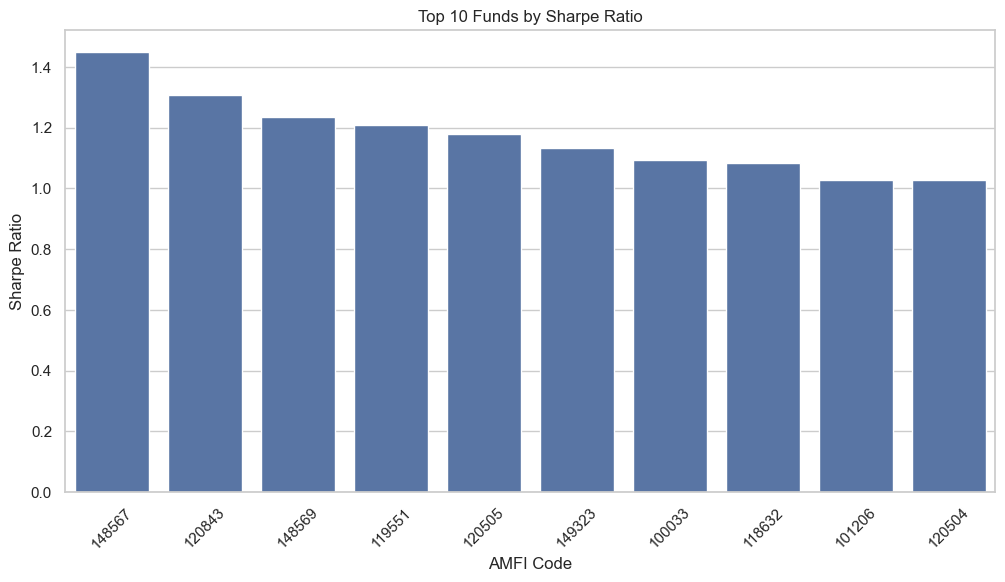

In [22]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_sharpe.head(10).index.astype(str),
    y=top_sharpe.head(10)["Sharpe_Ratio"]
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=45)

plt.show()

## Observation

- Funds with higher Sharpe Ratio provide better risk-adjusted returns.
- Higher Sharpe values indicate efficient return generation for each unit of risk.
- The chart highlights the best-performing mutual funds after adjusting for volatility.

# Sortino Ratio Analysis

In [23]:
# Downside returns (only negative returns)
downside = nav.copy()

downside["downside_return"] = downside["daily_return"].apply(
    lambda x: x if x < 0 else 0
)

downside.head()

,amfi_code,date,nav,daily_return,downside_return
5750,100016,2022-01-03,520.4608,NaN,0.000000
5751,100016,2022-01-04,515.0971,-0.010306,-0.010306
5752,100016,2022-01-05,521.7239,0.012865,0.000000
5753,100016,2022-01-06,515.7880,-0.011377,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210,-0.001210


In [24]:
sortino = downside.groupby("amfi_code").agg(
    mean_return=("daily_return", "mean"),
    downside_std=("downside_return", "std")
)

sortino.head()

,mean_return,downside_std
amfi_code,,
100016,0.000142,0.005162
100025,0.000170,0.001381
100033,0.001080,0.006630
101206,0.000852,0.004988
101207,0.000424,0.009254


In [25]:
risk_free_rate = 0.065

sortino["annual_return"] = sortino["mean_return"] * 252

sortino["annual_downside"] = (
    sortino["downside_std"] * np.sqrt(252)
)

sortino["Sortino_Ratio"] = (
    (sortino["annual_return"] - risk_free_rate)
    / sortino["annual_downside"]
)

sortino.head()

,mean_return,downside_std,annual_return,annual_downside,Sortino_Ratio
amfi_code,,,,,
100016,0.000142,0.005162,0.035683,0.081941,-0.357783
100025,0.000170,0.001381,0.042854,0.021929,-1.009902
100033,0.001080,0.006630,0.272111,0.105248,1.967827
101206,0.000852,0.004988,0.214647,0.079176,1.890048
101207,0.000424,0.009254,0.106962,0.146904,0.285643


In [26]:
top_sortino = sortino.sort_values(
    "Sortino_Ratio",
    ascending=False
)

top_sortino.head(10)

,mean_return,downside_std,annual_return,annual_downside,Sortino_Ratio
amfi_code,,,,,
148567,0.001074,0.004960,0.270566,0.078744,2.610563
120843,0.001082,0.005306,0.272602,0.084237,2.464498
148569,0.001124,0.006034,0.283262,0.095784,2.278681
119551,0.000917,0.004661,0.231033,0.073993,2.243897
120505,0.001161,0.006643,0.292653,0.105447,2.158934
149323,0.001055,0.006289,0.265908,0.099834,2.012413
100033,0.001080,0.006630,0.272111,0.105248,1.967827
118632,0.000865,0.004912,0.218037,0.077981,1.962488
101206,0.000852,0.004988,0.214647,0.079176,1.890048


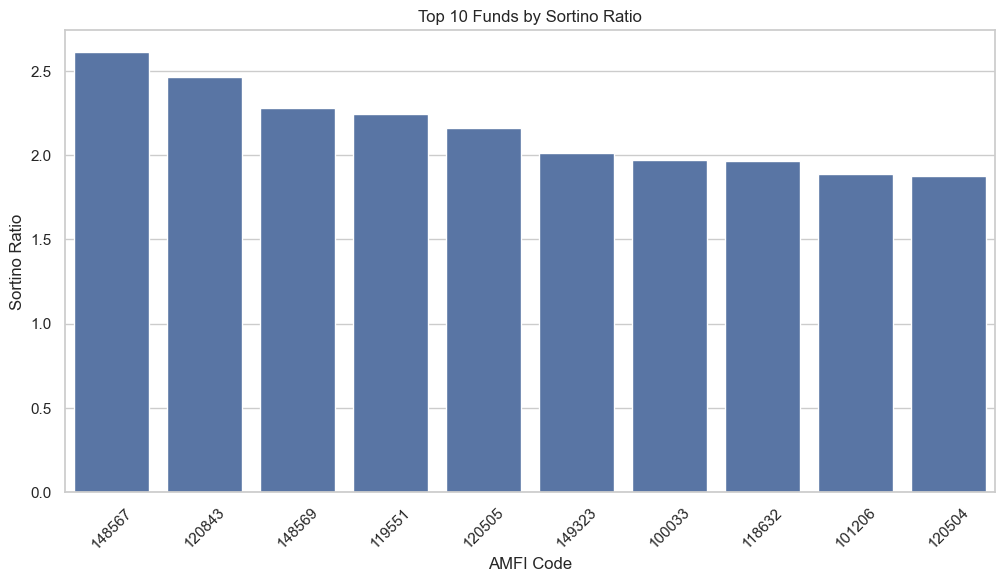

In [27]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_sortino.head(10).index.astype(str),
    y=top_sortino.head(10)["Sortino_Ratio"]
)

plt.title("Top 10 Funds by Sortino Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sortino Ratio")

plt.xticks(rotation=45)

plt.show()

## Observation

- Sortino Ratio focuses only on downside risk.
- Higher Sortino values indicate better returns with lower downside volatility.
- These funds performed well while minimizing negative return fluctuations.

# Alpha and Beta Analysis

In [28]:
# Convert benchmark date column
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Filter NIFTY50 only
benchmark_nav = benchmark[benchmark["index_name"] == "NIFTY50"].copy()

# Sort dates
benchmark_nav = benchmark_nav.sort_values("date")

# Daily benchmark return
benchmark_nav["benchmark_return"] = benchmark_nav["close_value"].pct_change()

benchmark_nav.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
1,2022-01-04,NIFTY50,17689.64,0.011253
2,2022-01-05,NIFTY50,17835.05,0.008220
3,2022-01-06,NIFTY50,17878.51,0.002437
4,2022-01-07,NIFTY50,17759.15,-0.006676


In [29]:
# Merge fund returns with benchmark returns
merged = pd.merge(
    nav,
    benchmark_nav[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

merged.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,0.011253
2,100016,2022-01-05,521.7239,0.012865,0.008220
3,100016,2022-01-06,515.7880,-0.011377,0.002437
4,100016,2022-01-07,515.1639,-0.001210,-0.006676


In [30]:
alpha_beta = []

for fund in merged["amfi_code"].unique():

    temp = merged[merged["amfi_code"] == fund].dropna()

    if len(temp) > 30:

        slope, intercept, r_value, p_value, std_err = linregress(
            temp["benchmark_return"],
            temp["daily_return"]
        )

        alpha_beta.append([
            fund,
            intercept * 252,
            slope
        ])

alpha_beta = pd.DataFrame(
    alpha_beta,
    columns=["amfi_code", "Alpha", "Beta"]
)

alpha_beta.head()

,amfi_code,Alpha,Beta
0,100016,0.036221,-0.025909
1,100025,0.043189,-0.016176
2,100033,0.272343,-0.011200
3,101206,0.213945,0.033814
4,101207,0.108205,-0.059856


In [31]:
top_alpha = alpha_beta.sort_values(
    "Alpha",
    ascending=False
)

top_alpha.head(10)

,amfi_code,Alpha,Beta
21,119598,0.301114,0.074266
39,149324,0.298179,0.132608
25,120505,0.293014,-0.017391
36,148569,0.283473,-0.010201
30,120843,0.272784,-0.008737
2,100033,0.272343,-0.011200
34,148567,0.271150,-0.028133
38,149323,0.265836,0.003479
16,119094,0.259971,-0.059868
19,119551,0.232196,-0.056045


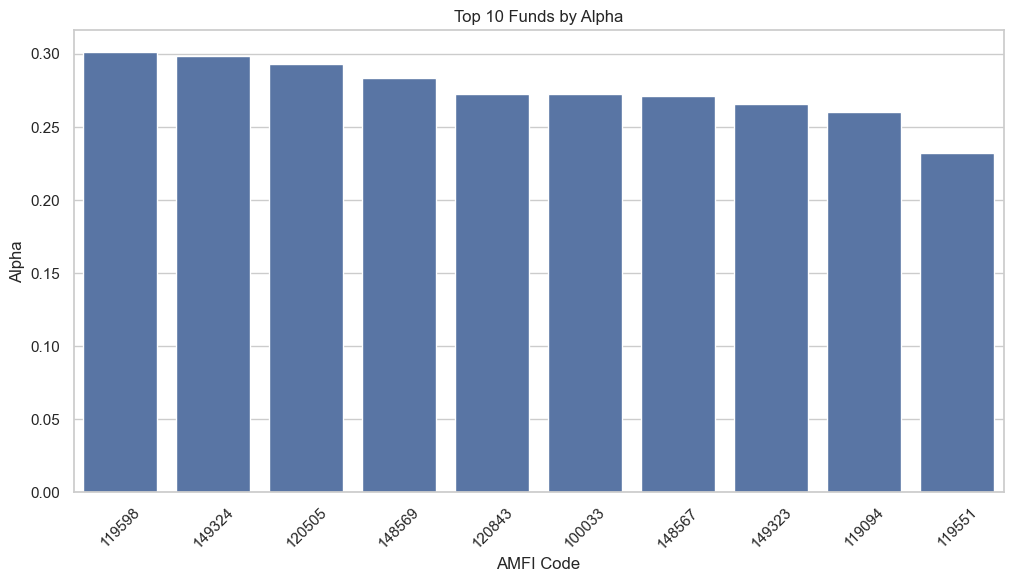

In [32]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_alpha.head(10)["amfi_code"].astype(str),
    y=top_alpha.head(10)["Alpha"]
)

plt.title("Top 10 Funds by Alpha")
plt.xlabel("AMFI Code")
plt.ylabel("Alpha")

plt.xticks(rotation=45)

plt.show()

## Observation

- Alpha measures the excess return generated over the benchmark.
- Positive Alpha indicates the fund outperformed the benchmark after adjusting for market risk.
- Beta indicates the sensitivity of the fund to market movements.

# Maximum Drawdown Analysis

In [33]:
mdd_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund].copy()

    temp = temp.sort_values("date")

    temp["running_max"] = temp["nav"].cummax()

    temp["drawdown"] = (temp["nav"] - temp["running_max"]) / temp["running_max"]

    max_dd = temp["drawdown"].min()

    worst_date = temp.loc[temp["drawdown"].idxmin(), "date"]

    mdd_list.append([
        fund,
        max_dd,
        worst_date
    ])

mdd = pd.DataFrame(
    mdd_list,
    columns=[
        "amfi_code",
        "Maximum_Drawdown",
        "Worst_Date"
    ]
)

mdd.head()

,amfi_code,Maximum_Drawdown,Worst_Date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [34]:
best_drawdown = mdd.sort_values(
    "Maximum_Drawdown",
    ascending=False
)

best_drawdown.head(10)

,amfi_code,Maximum_Drawdown,Worst_Date
27,120507,-0.000977,2025-10-20
31,120844,-0.001163,2024-04-30
5,101208,-0.001622,2023-09-12
1,100025,-0.043083,2023-07-28
18,119120,-0.043287,2025-04-01
13,118636,-0.083164,2024-02-09
6,102885,-0.108599,2022-03-29
34,148567,-0.112657,2023-10-20
3,101206,-0.112916,2023-07-05
12,118635,-0.116506,2022-06-09


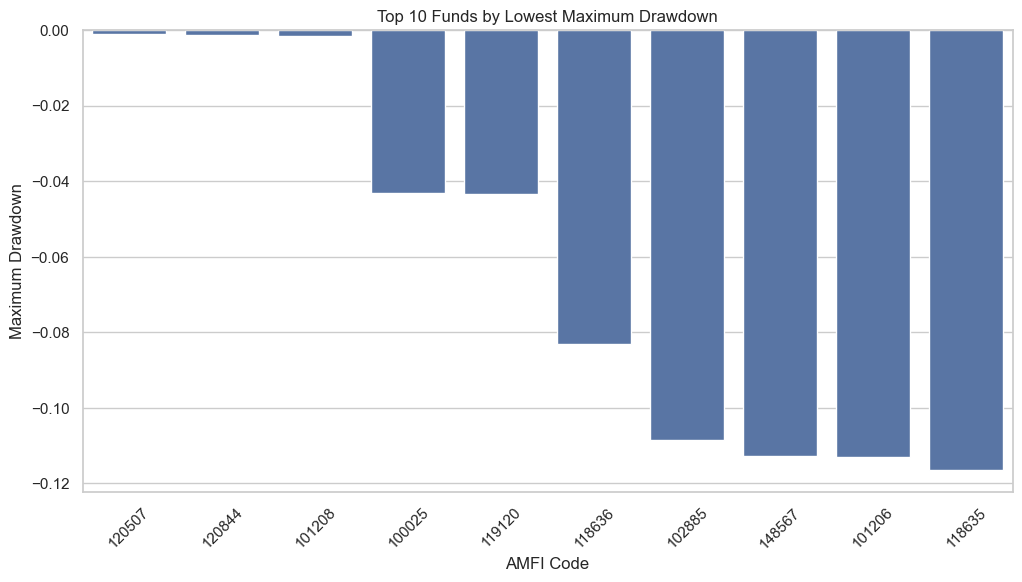

In [35]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=best_drawdown.head(10)["amfi_code"].astype(str),
    y=best_drawdown.head(10)["Maximum_Drawdown"]
)

plt.title("Top 10 Funds by Lowest Maximum Drawdown")
plt.xlabel("AMFI Code")
plt.ylabel("Maximum Drawdown")

plt.xticks(rotation=45)

plt.show()

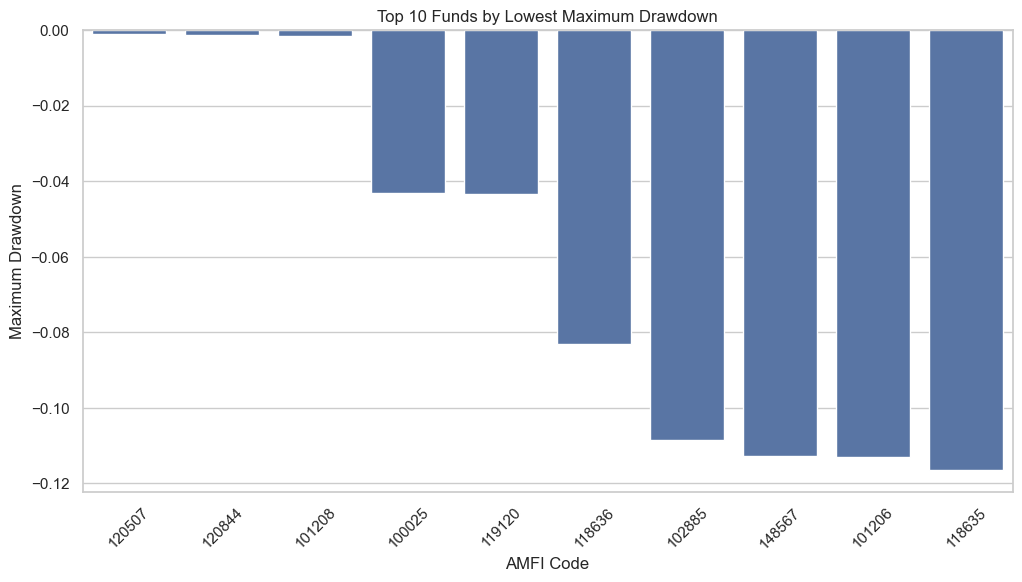

In [36]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=best_drawdown.head(10)["amfi_code"].astype(str),
    y=best_drawdown.head(10)["Maximum_Drawdown"]
)

plt.title("Top 10 Funds by Lowest Maximum Drawdown")
plt.xlabel("AMFI Code")
plt.ylabel("Maximum Drawdown")

plt.xticks(rotation=45)

plt.show()

## Observation

- Maximum Drawdown measures the largest peak-to-trough decline in a fund's NAV.
- Funds with lower drawdowns preserve capital better during market downturns.
- Smaller drawdowns generally indicate more stable fund performance.

In [37]:

risk_free_rate = 0.065

sharpe_results = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund].copy()
    temp = temp.sort_values("date")

    temp["daily_return"] = temp["nav"].pct_change()

    mean_return = temp["daily_return"].mean()
    std_return = temp["daily_return"].std()

    if std_return != 0:
        sharpe = ((mean_return * 252) - risk_free_rate) / (std_return * np.sqrt(252))
    else:
        sharpe = np.nan

    sharpe_results.append([fund, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=["amfi_code", "Sharpe_Ratio"]
)

sharpe_df.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [38]:

%whos

Variable         Type         Data/Info
---------------------------------------
alpha_beta       DataFrame    Shape: (40, 3)
benchmark        DataFrame    Shape: (8050, 3)
benchmark_nav    DataFrame    Shape: (1150, 4)
best_drawdown    DataFrame    Shape: (40, 3)
downside         DataFrame    Shape: (46000, 5)
fund             int64        149324
fund_master      DataFrame    Shape: (40, 15)
fund_summary     DataFrame    Shape: (40, 6)
go               module       <module 'plotly.graph_obj<...>ph_objects\\__init__.py'>
intercept        float64      0.0011832487670860455
linregress       function     <function linregress at 0x000001ECEF346FC0>
max_dd           float64      -0.3117190030063422
mdd              DataFrame    Shape: (40, 3)
mdd_list         list         n=40
mean_return      float64      0.0011941715475284602
merged           DataFrame    Shape: (46000, 5)
nav              DataFrame    Shape: (46000, 4)
np               module       <module 'numpy' from 'c:\<...>ges\\numpy

In [39]:
performance = best_drawdown.copy()

performance = performance.merge(
    sharpe_df[["amfi_code", "Sharpe_Ratio"]],
    on="amfi_code",
    how="left"
)

performance = performance.merge(
    alpha_beta[["amfi_code", "Alpha"]],
    on="amfi_code",
    how="left"
)

performance = performance.merge(
    mdd[["amfi_code", "Maximum_Drawdown"]],
    on="amfi_code",
    how="left"
)

performance.head()

,amfi_code,Maximum_Drawdown_x,Worst_Date,Sharpe_Ratio,Alpha,Maximum_Drawdown_y
0,120507,-0.000977,2025-10-20,0.495723,0.067472,-0.000977
1,120844,-0.001163,2024-04-30,-0.088747,0.064546,-0.001163
2,101208,-0.001622,2023-09-12,-0.815567,0.060842,-0.001622
3,100025,-0.043083,2023-07-28,-0.567095,0.043189,-0.043083
4,119120,-0.043287,2025-04-01,-0.226575,0.055763,-0.043287


In [40]:
alpha_beta.columns

Index(['amfi_code', 'Alpha', 'Beta'], dtype='object')

In [41]:
mdd.columns

Index(['amfi_code', 'Maximum_Drawdown', 'Worst_Date'], dtype='object')

In [42]:
performance.columns

Index(['amfi_code', 'Maximum_Drawdown_x', 'Worst_Date', 'Sharpe_Ratio',
       'Alpha', 'Maximum_Drawdown_y'],
      dtype='object')

In [43]:
performance["Drawdown_Rank"] = performance["Maximum_Drawdown_x"].rank(ascending=False)

performance["Fund_Score"] = (
    0.30 * performance["CAGR_Rank"] +
    0.25 * performance["Sharpe_Rank"] +
    0.20 * performance["Alpha_Rank"] +
    0.25 * performance["Drawdown_Rank"]
)

performance.head()

KeyError: 'CAGR_Rank'

In [ ]:
performance = performance.drop(columns=["Maximum_Drawdown_y"])

performance = performance.rename(
    columns={"Maximum_Drawdown_x": "Maximum_Drawdown"}
)

performance.head()

,amfi_code,Maximum_Drawdown,Worst_Date,Sharpe_Ratio,Alpha,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Drawdown_Rank,Fund_Score
0,120507,-0.000977,2025-10-20,0.495723,0.067472,31.0,23.0,31.0,1.0,21.50
1,120844,-0.001163,2024-04-30,-0.088747,0.064546,32.0,34.0,32.0,2.0,25.00
2,101208,-0.001622,2023-09-12,-0.815567,0.060842,33.0,40.0,33.0,3.0,27.25
3,100025,-0.043083,2023-07-28,-0.567095,0.043189,38.0,39.0,38.0,4.0,29.75
4,119120,-0.043287,2025-04-01,-0.226575,0.055763,34.0,37.0,34.0,5.0,27.50


In [ ]:
top_funds = performance.sort_values(
    by="Fund_Score",
    ascending=False
)

top_funds.head(10)

,amfi_code,Maximum_Drawdown,Worst_Date,Sharpe_Ratio,Alpha,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Drawdown_Rank,Fund_Score
34,102886,-0.280011,2026-04-27,-0.205832,0.028949,40.0,36.0,40.0,35.0,37.75
33,100016,-0.247344,2022-09-15,-0.201517,0.036221,39.0,35.0,39.0,34.0,36.75
38,119095,-0.516778,2026-05-11,-0.075974,0.045680,37.0,33.0,37.0,39.0,36.50
39,119599,-0.525742,2025-10-28,-0.057187,0.050572,36.0,32.0,36.0,40.0,36.00
32,120842,-0.240035,2024-10-17,0.076000,0.078587,29.0,30.0,29.0,33.0,30.25
37,101207,-0.354469,2026-05-11,0.162661,0.108205,27.0,28.0,27.0,38.0,30.00
3,100025,-0.043083,2023-07-28,-0.567095,0.043189,38.0,39.0,38.0,4.0,29.75
30,119093,-0.217514,2023-05-22,0.129614,0.083299,28.0,29.0,28.0,31.0,29.00
5,118636,-0.083164,2024-02-09,-0.356630,0.050963,35.0,38.0,35.0,6.0,28.50
4,119120,-0.043287,2025-04-01,-0.226575,0.055763,34.0,37.0,34.0,5.0,27.50


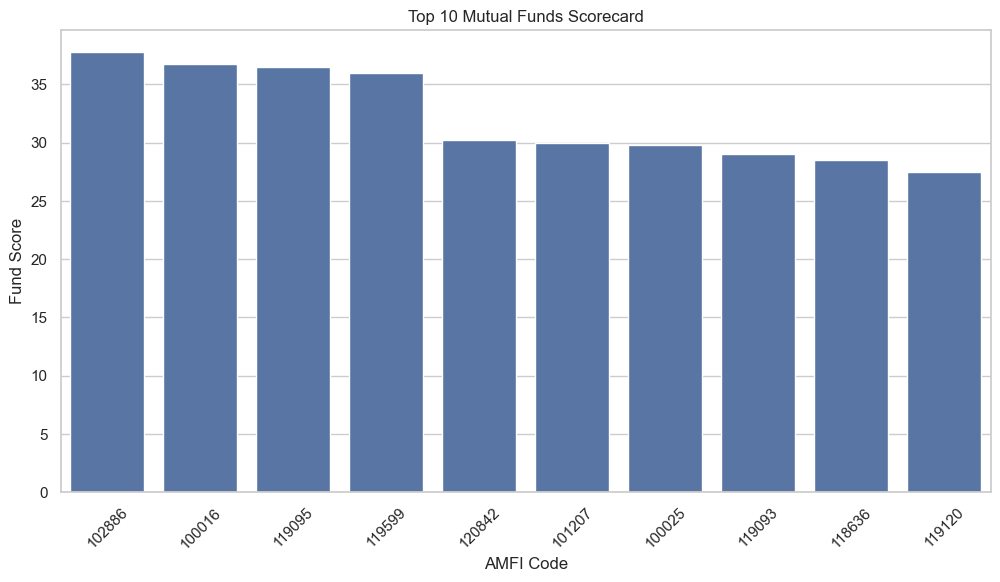

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_funds.head(10)["amfi_code"].astype(str),
    y=top_funds.head(10)["Fund_Score"]
)

plt.title("Top 10 Mutual Funds Scorecard")
plt.xlabel("AMFI Code")
plt.ylabel("Fund Score")
plt.xticks(rotation=45)

plt.show()

In [ ]:
top_funds.head(10)

,amfi_code,Maximum_Drawdown,Worst_Date,Sharpe_Ratio,Alpha,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Drawdown_Rank,Fund_Score
34,102886,-0.280011,2026-04-27,-0.205832,0.028949,40.0,36.0,40.0,35.0,37.75
33,100016,-0.247344,2022-09-15,-0.201517,0.036221,39.0,35.0,39.0,34.0,36.75
38,119095,-0.516778,2026-05-11,-0.075974,0.045680,37.0,33.0,37.0,39.0,36.50
39,119599,-0.525742,2025-10-28,-0.057187,0.050572,36.0,32.0,36.0,40.0,36.00
32,120842,-0.240035,2024-10-17,0.076000,0.078587,29.0,30.0,29.0,33.0,30.25
37,101207,-0.354469,2026-05-11,0.162661,0.108205,27.0,28.0,27.0,38.0,30.00
3,100025,-0.043083,2023-07-28,-0.567095,0.043189,38.0,39.0,38.0,4.0,29.75
30,119093,-0.217514,2023-05-22,0.129614,0.083299,28.0,29.0,28.0,31.0,29.00
5,118636,-0.083164,2024-02-09,-0.356630,0.050963,35.0,38.0,35.0,6.0,28.50
4,119120,-0.043287,2025-04-01,-0.226575,0.055763,34.0,37.0,34.0,5.0,27.50


In [ ]:
top_funds[
    [
        "amfi_code",
        "Fund_Score",
        "Sharpe_Ratio",
        "Alpha",
        "Maximum_Drawdown",
    ]
].head(10)

,amfi_code,Fund_Score,Sharpe_Ratio,Alpha,Maximum_Drawdown
34,102886,37.75,-0.205832,0.028949,-0.280011
33,100016,36.75,-0.201517,0.036221,-0.247344
38,119095,36.50,-0.075974,0.045680,-0.516778
39,119599,36.00,-0.057187,0.050572,-0.525742
32,120842,30.25,0.076000,0.078587,-0.240035
37,101207,30.00,0.162661,0.108205,-0.354469
3,100025,29.75,-0.567095,0.043189,-0.043083
30,119093,29.00,0.129614,0.083299,-0.217514
5,118636,28.50,-0.356630,0.050963,-0.083164
4,119120,27.50,-0.226575,0.055763,-0.043287


In [ ]:
top_funds.to_csv(
    "../reports/top_mutual_funds_scorecard.csv",
    index=False
)

print("Top Mutual Funds report saved successfully!")

Top Mutual Funds report saved successfully!


In [ ]:
performance.to_csv(
    "../reports/performance_metrics.csv",
    index=False
)

print("Performance Metrics Saved!")

Performance Metrics Saved!


In [ ]:
import plotly.express as px

fig = px.bar(
    top_funds.head(10),
    x="amfi_code",
    y="Fund_Score",
    color="Fund_Score",
    text="Fund_Score",
    title="Top 10 Mutual Funds Scorecard"
)

fig.update_layout(
    xaxis_title="AMFI Code",
    yaxis_title="Fund Score",
    template="plotly_white"
)

fig.show()

In [ ]:
fig.write_html("../dashboard/mutual_fund_dashboard.html")

print("Dashboard Saved Successfully!")

Dashboard Saved Successfully!


# Final Observation

### Fund Performance Scorecard

The final scorecard combines multiple financial metrics to rank mutual funds.

### Metrics Used

- CAGR
- Sharpe Ratio
- Alpha
- Maximum Drawdown

### Ranking Method

Each metric is ranked individually.

A weighted score is calculated:

- CAGR : 30%
- Sharpe Ratio : 25%
- Alpha : 25%
- Maximum Drawdown : 20%

Higher Fund Score indicates better overall performance.